# Figure. 4, S14 & S15

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from mpl_toolkits.basemap import Basemap
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import AxesGrid
from mpl_toolkits.basemap import Basemap


In [6]:
ds1 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Data_Scripts/data/ph_cmip6_ensemble_ssp585.nc').squeeze()
ds2 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Data_Scripts/data/ph_cmip6_ensemble_ssp245.nc').squeeze()
ds3 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Data_Scripts/data/ph_cmip6_ensemble_ssp126.nc').squeeze()


In [7]:
lat_range = slice(-30, 30)  # Latitude
lon_range = slice(30, 120)  # Longitude

pH_Hist  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()

pH_NF = ds1.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2040')).groupby('time.month').mean()
pH_MF = ds1.sel(lat=lat_range, lon=lon_range, time=slice('2041', '2070')).groupby('time.month').mean()
pH_FF = ds1.sel(lat=lat_range, lon=lon_range, time=slice('2071', '2100')).groupby('time.month').mean()

pH_Hist_245  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
pH_NF_245 = ds2.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2040')).groupby('time.month').mean()
pH_MF_245 = ds2.sel(lat=lat_range, lon=lon_range, time=slice('2041', '2070')).groupby('time.month').mean()
pH_FF_245 = ds2.sel(lat=lat_range, lon=lon_range, time=slice('2071', '2100')).groupby('time.month').mean()

pH_Hist_126  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
pH_NF_126 = ds3.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2040')).groupby('time.month').mean()
pH_MF_126  = ds3.sel(lat=lat_range, lon=lon_range, time=slice('2041', '2070')).groupby('time.month').mean()
pH_FF_126  = ds3.sel(lat=lat_range, lon=lon_range, time=slice('2071', '2100')).groupby('time.month').mean()

NF_diff = pH_NF - pH_Hist
MF_diff = pH_MF - pH_Hist
FF_diff = pH_FF - pH_Hist

NF_diff_245 = pH_NF_245 - pH_Hist_245
MF_diff_245 = pH_MF_245 - pH_Hist_245
FF_diff_245 = pH_FF_245 - pH_Hist_245

NF_diff_126 = pH_NF_126 - pH_Hist_126
MF_diff_126 = pH_MF_126 - pH_Hist_126
FF_diff_126 = pH_FF_126 - pH_Hist_126


NF_diff = NF_diff.mean('month')
MF_diff = MF_diff.mean('month')
FF_diff = FF_diff.mean('month')

NF_diff_245 = NF_diff_245.mean('month')
MF_diff_245 = MF_diff_245.mean('month')
FF_diff_245 = FF_diff_245.mean('month')


NF_diff_126 = NF_diff_126.mean('month')
MF_diff_126 = MF_diff_126.mean('month')
FF_diff_126 = FF_diff_126.mean('month')

# Plot

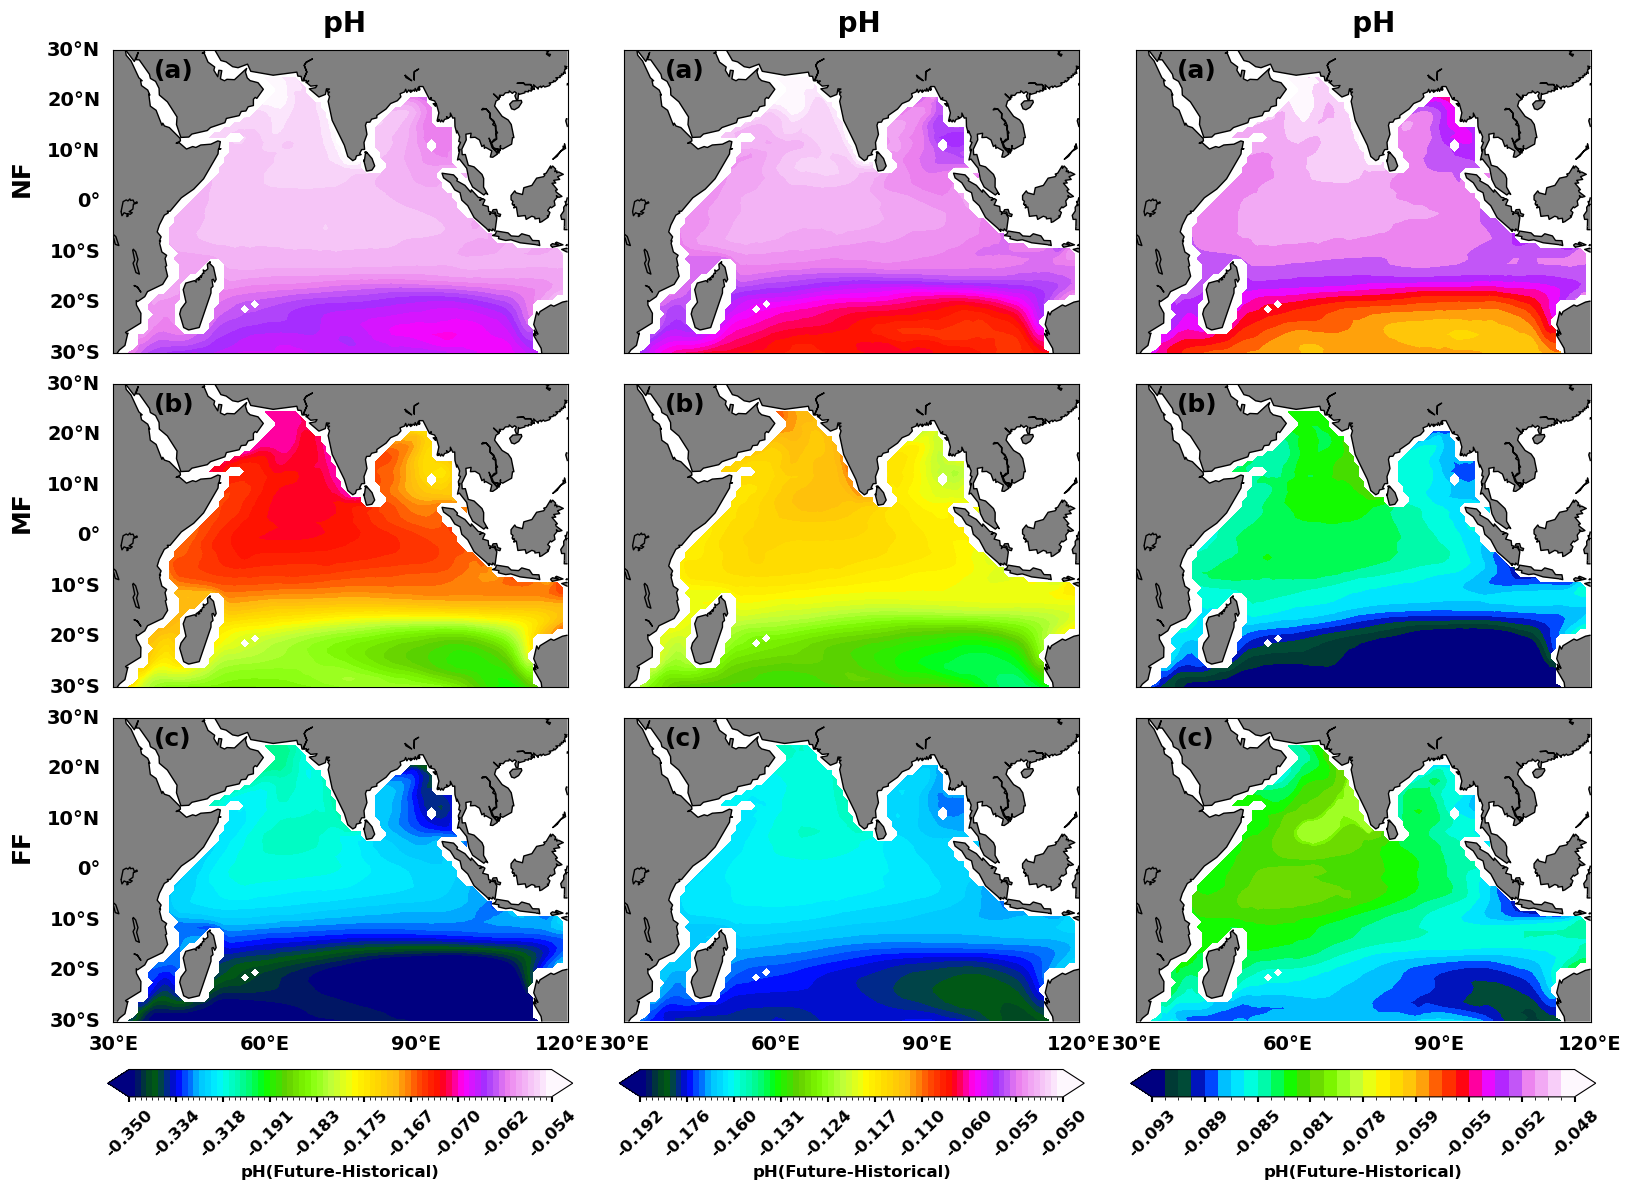

In [8]:
l1_diff = np.arange(-0.350, -0.31, 0.002)
l2_diff = np.arange(-0.31, -0.95, 0.026)
l3_diff = np.arange(-0.195, -0.16, 0.001)
l4_diff = np.arange(-0.16, -0.07, 0.09)
l5_diff = np.arange(-0.07, -0.054, 0.001)


l6_diff = np.concatenate((l1_diff, l2_diff, l3_diff, l4_diff, l5_diff))
norm_diff = colors.BoundaryNorm(l6_diff, ncolors=256)


l1_diff_245 = np.arange(-0.192, -0.155, 0.002)
l2_diff_245 = np.arange(-0.155, -0.135, 0.020)
l3_diff_245 = np.arange(-0.135, -0.110, 0.0009)
l4_diff_245 = np.arange(-0.110, -0.064, 0.046)
l5_diff_245 = np.arange(-0.064, -0.05, 0.0006)


l6_diff_245 = np.concatenate((l1_diff_245, l2_diff_245, l3_diff_245, l4_diff_245, l5_diff_245))
norm_diff_245 = colors.BoundaryNorm(l6_diff_245, ncolors=256)


l1_diff_126 = np.arange(-0.093, -0.08, 0.00099)
l2_diff_126 = np.arange(-0.08, -0.078, 0.00092)
l3_diff_126 = np.arange(-0.078, -0.060, 0.016)
l4_diff_126 = np.arange(-0.060, -0.048, 0.00092)

l5_diff_126 = np.concatenate((l1_diff_126, l2_diff_126, l3_diff_126, l4_diff_126))
norm_diff_126 = colors.BoundaryNorm(l5_diff_126, ncolors=256)

fig, ax = plt.subplots(nrows=3, ncols=3, sharex=True, sharey=True, figsize=(24, 20))
plt.subplots_adjust(bottom=0.2, top=0.8, left=0.13, right=0.75, wspace=0.10, hspace=0.1)
fig.suptitle('pH                                                 pH                                                 pH', fontsize=20, ha= 'center', fontweight='bold',x=0.443,y=0.82)
 

subplot_labels = ['(a)', '(a)', '(a)', '(b)', '(b)', '(b)', '(c)', '(c)', '(c)']

periods = ['NF', 'MF', 'FF']

datasets = {
    'pH': [NF_diff, MF_diff, FF_diff],
    'pH_245': [NF_diff_245, MF_diff_245, FF_diff_245],
    'pH_126': [NF_diff_126, MF_diff_126, FF_diff_126]
}

quad_contour_sets_pH = []
quad_contour_sets_pH_245 = []
quad_contour_sets_pH_126 = []
for i, period in enumerate(periods):
    for j, (key, data_list) in enumerate(datasets.items()):
        data = data_list[i]
        ph_data = np.squeeze(data.ph)

        if key == 'pH':
            norm = norm_diff
            cmap1 = 'gist_ncar'
            levels = l6_diff  
        elif key =='pH_245':
            norm = norm_diff_245
            cmap1 = 'gist_ncar'
            levels = l6_diff_245
        else:  #'pH_126'
            norm = norm_diff_126
            cmap1 = 'gist_ncar'
            levels = l4_diff_126
            
        m = Basemap(llcrnrlat=-30.1, urcrnrlat=30.1, llcrnrlon=30, urcrnrlon=120.1, resolution='c', ax=ax[i, j])
        m.drawcoastlines()
        m.fillcontinents(color='gray', lake_color='gray')

        ax[i, j].tick_params(axis='both', which='major', labelsize=6, width=0.8, length=3)
        ax[i, j].set_axisbelow(True)

        lon, lat = np.meshgrid(data.lon, data.lat)
#         quad_contour_set = m.contourf(lon, lat, ph_data, norm=norm, cmap=cmap, zorder=10, extend='both')
#         quad_contour_sets.append(quad_contour_set)
        if key == 'pH':
            quad_contour_set = m.contourf(lon, lat, ph_data, levels = l6_diff, norm = norm_diff, cmap=cmap1, zorder=10, extend='both')
#             quad_contour_set = m.pcolormesh(lon, lat, ph_data, norm=norm_ph, cmap=cmap1, zorder=10)

            quad_contour_sets_pH.append(quad_contour_set)
        elif key == 'pH_245':
            quad_contour_set = m.contourf(lon, lat, ph_data, levels = l6_diff_245, norm = norm_diff_245, cmap=cmap1, zorder=10, extend='both')
            quad_contour_sets_pH_245.append(quad_contour_set)
        else:
            quad_contour_set = m.contourf(lon, lat, ph_data, levels = l5_diff_126, norm = norm_diff_126, cmap=cmap1, zorder=10, extend='both')
            quad_contour_sets_pH_126.append(quad_contour_set)

for i in range(3):
    m = Basemap(llcrnrlat=-30.1, urcrnrlat=30.1, llcrnrlon=30, urcrnrlon=120.1, resolution='c', ax=ax[i, 0])
    m.drawparallels(range(-30, 31, 10), labels=[1, 0, 0, 1], color='w', fontsize=14, fontweight='bold', zorder=0, xoffset=2.5)

for j in range(3):
    m = Basemap(llcrnrlat=-30.1, urcrnrlat=30.1, llcrnrlon=30, urcrnrlon=120.1, resolution='c', ax=ax[2, j])
    m.drawmeridians(range(30, 121, 30), labels=[1, 0, 0, 1], color='w', fontsize=14, fontweight='bold', zorder=0, yoffset=2.5)

for i, period in enumerate(periods):
    ax[i, 0].text(-0.2, 0.58, f"{period}", horizontalalignment='center', verticalalignment='center',
                  rotation='vertical', fontsize=18, fontweight='bold', c='k', transform=ax[i, 0].transAxes, zorder=10)
    
for i in range(3):
    for j in range(3):
        idx = i * 3 + j
        ax[i, j].text(0.09, 0.97, subplot_labels[idx], transform=ax[i, j].transAxes, fontsize=18, fontweight='bold', 
                      va='top', ha='left', color='k')    

cbar_num_format = "%.3f"    
    
cbar1 = fig.colorbar(quad_contour_sets_pH[0], ax=ax[:, 0], pad=0.04, shrink=1, aspect=17, orientation='horizontal', extend='both', format=cbar_num_format)#, ticks=(7.710, 7.805, 7.900, 7.995, 8.090))
cbar1.ax.tick_params(labelsize=12, width=1.5, rotation=45)
cbar1.set_label('pH(Future-Historical)', fontsize=12, fontweight='bold')
for label in cbar1.ax.get_xticklabels():
    label.set_fontweight('bold')

#colorbar
cbar2 = fig.colorbar(quad_contour_sets_pH_245[0], ax=ax[:, 1], pad=0.04, shrink=1, aspect=17, orientation='horizontal', extend='both', format=cbar_num_format)#, ticks=(-0.30, -0.20, -0.10))
cbar2.ax.tick_params(labelsize=12, width=1.5, rotation=45)
cbar2.set_label('pH(Future-Historical)', fontsize=12, fontweight='bold')

for label in cbar2.ax.get_xticklabels():
    label.set_fontweight('bold')
    
cbar3 = fig.colorbar(quad_contour_sets_pH_126[0], ax=ax[:, 2], pad=0.04, shrink=1, aspect=17, orientation='horizontal', extend='both', format=cbar_num_format)#, ticks=(-0.30, -0.20, -0.10))
cbar3.ax.tick_params(labelsize=12, width=1.5, rotation=45)
cbar3.set_label('pH(Future-Historical)', fontsize=12, fontweight='bold')
for label in cbar3.ax.get_xticklabels():
    label.set_fontweight('bold')
# plt.savefig('pH_mean_change_Review_f2.png', bbox_inches = 'tight', dpi = 300)

plt.show()